# CPSC 6440 01 / AMTH 3220 01 / CPSC 4844 01 / MATH 5220 01 / MATH 7440 01 - Problem Set 2

# Instructions:
- Run each cell in sequence.
- Fill in the missing parts (marked as TODO).
- Test your implementation using the datasets provided.


# Use MIOFlow to infer trajectories on PHATE space

Prerequisites:
- You have preprocessed your data and saved a mioflow DataFrame [notebook: 3-time-pseudotime]: 
    - rows are cells
    - columns are embeddings dimensions
    - "samples" are the discrete time labels


In this notebook, we will:
- Run MIOFlow on our PHATE space to infer trajectories

## 1. Importing MIOFlow and defining data paths

In [31]:
import random
import ot
import torch
import torch.nn as nn
from torch.nn  import functional as F 
from torchdiffeq import odeint_adjoint as odeint
import torchsde
from tqdm import tqdm
import itertools
from matplotlib.lines import Line2D
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
PROCESSED_DATA_DIR = os.path.join('../../data', 'processed')
RESULTS_DIR = os.path.join('../../results')

data_name = 'scRNAseq'
SAVE_PATH = os.path.join(RESULTS_DIR, data_name)


## 1. Retrieve the data and embedding normalization
First we retrieve the data.

Then, we will normalize the embeddings as a standard procedure to enable our network to learn better.

**Attention:** It is important to save the _std_ and _mean_ values. 

It is important to save the _std_ and _mean_ values because when decoding back using the `DimChanger`, we need to ensure that the outputs follow the distributions of the initial embeddings.

In [32]:
data = pd.read_csv(os.path.join(SAVE_PATH,'mioflow_data.csv'))
data.head(1)

,d1,d2,samples
0,-0.035623,-0.008487,0


In [33]:
# Get embedding columns dynamically
embed_cols = [col for col in data.columns if col.startswith('d') and col[1:].isdigit()] # Retrieve the columns that start with a d
embedding = data[embed_cols].values
embedding

array([[-0.03562276, -0.0084874 ],
       [-0.03204078, -0.00272053],
       [-0.02482219,  0.00586843],
       ...,
       [ 0.02312691, -0.0032905 ],
       [ 0.0251625 , -0.00373983],
       [ 0.02061857, -0.00167268]])

### Normalizing the data

In [34]:
# Normalize across all dimensions properly
mean_vals = np.mean(embedding, axis=0)
std_vals = np.std(embedding, axis=0)
std_vals = np.where(std_vals == 0, 1, std_vals)  # Prevent division by zero
normalized = (embedding - mean_vals) / std_vals
# Normalized that is going to be used to train the network
normalized

array([[-2.06283334, -0.67810267],
       [-1.85814333, -0.21370189],
       [-1.44564181,  0.47796024],
       ...,
       [ 1.29437854, -0.25960056],
       [ 1.41070147, -0.29578539],
       [ 1.15104143, -0.12931918]])

In [35]:
# We create the dataframe with the normalized data and the samples
df = pd.DataFrame(normalized, columns=[f'd{i+1}' for i in range(normalized.shape[1])])
df['samples'] = data['samples']
df.head(1)

,d1,d2,samples
0,-2.062833,-0.678103,0


In [36]:
# Retrieve the number of samples that are in the less representative class.
min_count = df['samples'].value_counts().min()

### Let's visualize what will be our input data using PHATE

If your data looks right, and we can see a path for the trajectories to follow, we can move on to training the MIOFlow algorithm

<Axes: xlabel='d1', ylabel='d2'>

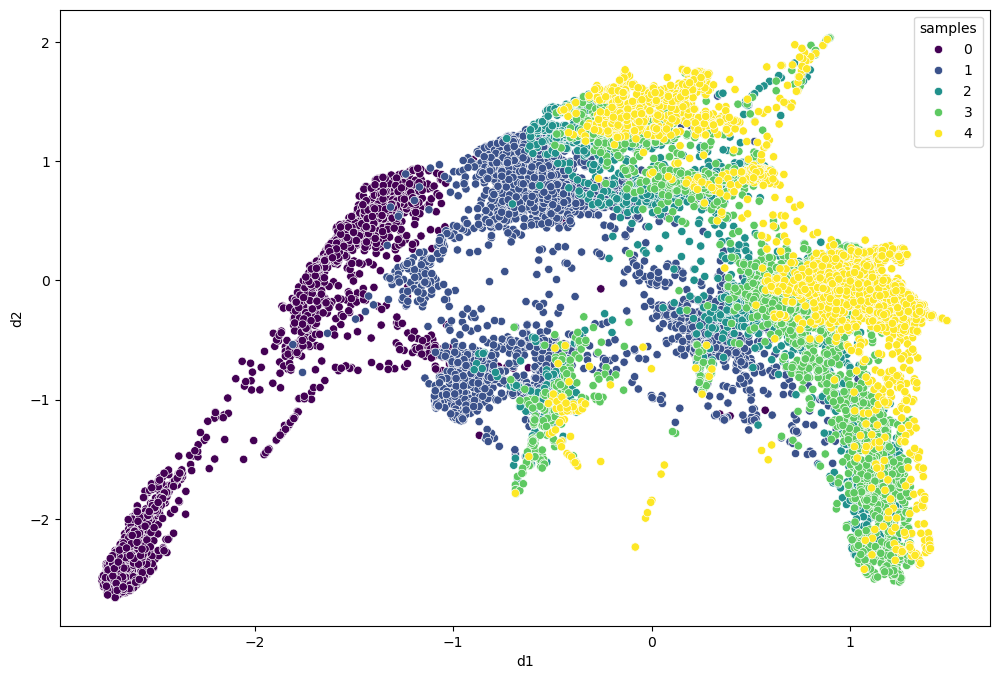

In [37]:
fig = plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='d1', y='d2', hue='samples', palette='viridis')

# Training the MIOFlow Model

A lot of this initial cells will be just setting up configurations to run the MIOFlow algorithm.

In [38]:
def set_seeds(seed:int):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [39]:
# Import torch library and verify if GPUs are available to be used.
import torch
set_seeds(0)
use_cuda = torch.cuda.is_available()

Here we define our ODE model

In [40]:
class ToyODE(nn.Module):
    """ 
    ODE derivative network
    
    feature_dims (int) default '5': dimension of the inputs, either in ambient space or embedded space.
    layer (list of int) defaulf ''[64]'': the hidden layers of the network.
    activation (torch.nn) default '"ReLU"': activation function applied in between layers.
    scales (NoneType|list of float) default 'None': the initial scale for the noise in the trajectories. One scale per bin, add more if using an adaptative ODE solver.
    n_aug (int) default '1': number of added dimensions to the input of the network. Total dimensions are features_dim + 1 (time) + n_aug. 
    
    Method
    forward (Callable)
        forward pass of the ODE derivative network.
        Parameters:
        t (torch.tensor): time of the evaluation.
        x (torch.tensor): position of the evalutation.
        Return:
        derivative at time t and position x.   
    """
    def __init__(
        self, 
        feature_dims=5,
        layers=[64],
        activation='ReLU',
        scales=None,
        n_aug=2,
        momentum_beta = 0.0,
        condition_dims=0, # TODO: make it a dict instead of assuming first!
    ):
        super(ToyODE, self).__init__()
        steps = [feature_dims+1+n_aug, *layers, feature_dims]
        pairs = zip(steps, steps[1:])
        self.condition_dim = condition_dims # TODO: make it a dict instead of assuming first!
        chain = list(itertools.chain(*list(zip(
            map(lambda e: nn.Linear(*e), pairs), 
            itertools.repeat(getattr(nn, activation)())
        ))))[:-1]

        self.chain = chain
        self.seq = (nn.Sequential(*chain))
        # self.initialize_final_layer()

        self.alpha = nn.Parameter(torch.tensor(scales, requires_grad=True).float()) if scales is not None else None
        self.n_aug = n_aug  

        self.momentum_beta = momentum_beta
        self.previous_v = None
   
        
    def forward(self, t, x): #NOTE the forward pass when we use torchdiffeq must be forward(self,t,x)
        zero = torch.tensor([0]).cuda() if x.is_cuda else torch.tensor([0])
        zeros = zero.repeat(x.size()[0],self.n_aug)
        time = t.repeat(x.size()[0],1)
        aug = torch.cat((x,time,zeros),dim=1)
        dxdt = self.seq(aug)
        if self.alpha is not None:
            z = torch.randn(x.size(),requires_grad=False).cuda() if x.is_cuda else torch.randn(x.size(),requires_grad=False)
            dxdt = dxdt + z*self.alpha[int(t-1)]

        if self.momentum_beta > 0.0:
            if self.previous_v is None or self.previous_v.shape[0] != x.shape[0]:
                self.previous_v = torch.zeros_like(dxdt)

            dxdt = self.momentum_beta * self.previous_v + (1 - self.momentum_beta) * dxdt
            self.previous_v = dxdt.detach()
        return dxdt

In [41]:
class ToyModel(nn.Module):
    """ 
    Neural ODE
        func (nn.Module): The network modeling the derivative.
        method (str) defaulf '"rk4"': any methods from torchdiffeq.
        rtol (NoneType | float): the relative tolerance of the ODE solver.
        atol (NoneType | float): the absolute tolerance. of the ODE solver.
        use_norm (bool): if True keeps the norm of func.
        norm (list of torch.tensor): the norm of the derivative.
        
        Method
        forward (Callable)
            x (torch.tensor): the initial sample
            t (torch.tensor) time points where we suppose x is from t[0]
            return the last sample or the whole seq.      
    """
    
    def __init__(self, func, method='rk4', rtol=None, atol=None, use_norm=False):
        super(ToyModel, self).__init__()        
        self.func = func
        self.method = method
        self.rtol=rtol
        self.atol=atol
        self.use_norm = use_norm
        self.norm=[]

    def forward(self, x, t, return_whole_sequence=False):

        if self.use_norm:
            for time in t: 
                self.norm.append(torch.linalg.norm(self.func(time,x)).pow(2))
        x = odeint(self.func,x ,t, method=self.method)         
       
        x = x[-1] if not return_whole_sequence else x
        return x

    def train(self, mode=True):
        # reset the norm
        super().train(mode)
        self.norm = []

    def eval(self):
        super().eval()
        self.norm = []

In [42]:
def make_model(
    feature_dims=5,
    layers=[64],
    output_dims=5,
    activation='ReLU',
    which='ode',
    method='rk4',
    rtol=None,
    atol=None,
    scales=None,
    n_aug=2,
    noise_type='diagonal', sde_type='ito',
    adjoint_method=None,
    use_norm=False,
    use_cuda=False,
    in_features=2, out_features=2, gunc=None,
    n_conditions=0,
    momentum_beta = 0.0,
):
    """
    Creates the 'ode' model or 'sde' model or the Geodesic Autoencoder. 
    See the parameters of the respective classes.
    """
    if which == 'ode' and n_conditions == 0:
        ode = ToyODE(feature_dims, layers, activation,scales,n_aug)
        model = ToyModel(ode,method,rtol, atol, use_norm=use_norm)
    if use_cuda:
        model.cuda()
    return model 

# Generating Trajectories Helper functions

In [43]:
def generate_steps(groups):
    return list(zip(groups[:-1], groups[1:]))

In [44]:
def group_extract(df, group, index='samples', groupby='samples'):
    return df.groupby(groupby).get_group(group).set_index(index).values
def sample(data, group, size=(100, ), replace=False, to_torch=False, use_cuda=False):
    sub = group_extract(data, group)
    idx = np.arange(sub.shape[0])
    sampled = sub[np.random.choice(idx, size=size, replace=replace)]
    if to_torch:
        sampled = torch.Tensor(sampled).float()
        if use_cuda:
            sampled = sampled.cuda()
    return sampled

def to_np(data):
    return data.detach().cpu().numpy()

In [45]:
def generate_points(
    model, df, n_points=100, 
    sample_with_replacement=False, use_cuda=False, 
    samples_key='samples', sample_time=None, autoencoder=None, recon=False
):
    '''
    Arguments:
    ----------
        model (torch.nn.Module): Trained network with the property `ode` corresponding to a `NeuralODE(ODEF())`.
            See `MIOFlow.ode` for more.
        df (pd.DataFrame): DataFrame containing a column for the timepoint samples and the rest of the data.
        n_points (int): Number of points to generate.
        sample_with_replacement (bool): Defaults to `False`. Whether or not to use replacement when sampling
            initial timepoint.
        use_cuda (bool): Defaults to `False`. Whether or not to use cuda.
        samples_key (str): Defaults to `'samples'`. The column in the `df` which has the timepoint groups.
        sample_time (list | None): Defaults to `None`. If `None` uses the group numbers in order as the 
            timepoints as specified in the column `df[samples_key]`.
        autoencoder (nn.Module|NoneType): Default to None, the trained autoencoder.
        recon (bool): Default to 'False', whether to use the autoencoder for reconstruction.
    Returns:
    ----------
        generated (float[float[]]): a list with shape `(len(sample_time), n_points, len(df.columns) - 1)`
            of the generated points.
    '''
    to_torch = True #if use_cuda else False

    groups = sorted(df[samples_key].unique())
    if sample_time is None:
        sample_time = groups
    data_t0 = sample(
        df, np.min(groups), size=(n_points, ), 
        replace=sample_with_replacement, to_torch=to_torch, use_cuda=use_cuda
    )
    if autoencoder is not None and recon:
        data_t0 = torch.Tensor(data_t0).float()
        data_t0 = autoencoder.encoder(data_t0)
        
    time =  torch.Tensor(sample_time).cuda() if use_cuda else torch.Tensor(sample_time)
    generated = model(data_t0, time, return_whole_sequence=True)
    if autoencoder is not None and recon:
        generated = autoencoder.decoder(generated)
    return to_np(generated)

def generate_trajectories(
    model, df, n_trajectories=30, n_bins=100, 
    sample_with_replacement=False, use_cuda=False, samples_key='samples',autoencoder=None, recon=False
):
    '''
    Arguments:
    ----------
        model (torch.nn.Module): Trained network with the property `ode` corresponding to a `NeuralODE(ODEF())`.
            See `MIOFlow.ode` for more.
        df (pd.DataFrame): DataFrame containing a column for the timepoint samples and the rest of the data.
        n_trajectories (int): Number of trajectories to generate.
        n_bins (int): Number of bins to use for the trajectories. More makes it smoother. Defaults to `100`.
        sample_with_replacement (bool): Defaults to `False`. Whether or not to use replacement when sampling
            initial timepoint.
        use_cuda (bool): Defaults to `False`. Whether or not to use cuda.
        samples_key (str): Defaults to `'samples'`. The column in the `df` which has the timepoint groups.
        autoencoder (nn.Module|NoneType): Default to None, the trained autoencoder.
        recon (bool): Default to 'False', whether to use the autoencoder for reconstruction.
    Returns:
    ----------
        trajectories (float[float[]]): a list with shape `(n_bins, n_points, len(df.columns) - 1)`
            of the generated trajectories.
    '''
    groups = sorted(df[samples_key].unique())
    sample_time = np.linspace(np.min(groups), np.max(groups), n_bins)
    trajectories = generate_points(model, df, n_trajectories, sample_with_replacement, use_cuda, samples_key, sample_time,autoencoder=autoencoder, recon=recon)
    return trajectories
    
def generate_plot_data(
    model, df, n_points, n_trajectories, n_bins, 
    sample_with_replacement=False, use_cuda=False, samples_key='samples',
    logger=None, autoencoder=None, recon=False
):
    '''
    Arguments:
    ----------
        model (torch.nn.Module): Trained network with the property `ode` corresponding to a `NeuralODE(ODEF())`.
            See `MIOFlow.ode` for more.
        df (pd.DataFrame): DataFrame containing a column for the timepoint samples and the rest of the data.
        n_points (int): Number of points to generate.
        n_trajectories (int): Number of trajectories to generate.
        n_bins (int): Number of bins to use for the trajectories. More makes it smoother. Defaults to `100`.
        sample_with_replacement (bool): Defaults to `False`. Whether or not to use replacement when sampling
            initial timepoint.
        use_cuda (bool): Defaults to `False`. Whether or not to use cuda.
        samples_key (str): Defaults to `'samples'`. The column in the `df` which has the timepoint groups.
        autoencoder (nn.Module|NoneType): Default to None, the trained autoencoder.
        recon (bool): Default to 'False', whether to use the autoencoder for reconstruction.
    Returns:
    ----------
        points (float[float[]]): a list with shape `(len(df[sample_key].unique()), n_points, len(df.columns) - 1)`
            of the generated points.
        trajectories (float[float[]]): a list with shape `(n_bins, n_points, len(df.columns) - 1)`
            of the generated trajectories.
    '''
    if logger: logger.info(f'Generating points')
    points = generate_points(model, df, n_points, sample_with_replacement, use_cuda, samples_key, None, autoencoder=autoencoder, recon=recon)
    if logger: logger.info(f'Generating trajectories')
    trajectories = generate_trajectories(model, df, n_trajectories, n_bins, sample_with_replacement, use_cuda, samples_key, autoencoder=autoencoder, recon=recon)
    return points, trajectories

# Defining Losses here

In [46]:
class OT_loss(nn.Module):
    _valid = 'emd sinkhorn sinkhorn_knopp_unbalanced'.split()

    def __init__(self, which='emd', use_cuda=True, detach_mass=True, detach_dist_for_plan=True, sinkhorn_lambda=2.0, covariance_lambda=0.0):
        if which not in self._valid:
            raise ValueError(f'{which} not known ({self._valid})')
        elif which == 'emd':
            self.fn = lambda m, n, M: ot.emd(m, n, M)
        elif which == 'sinkhorn':
            self.fn = lambda m, n, M : ot.sinkhorn(m, n, M, sinkhorn_lambda)
        elif which == 'sinkhorn_knopp_unbalanced':
            self.fn = lambda m, n, M : ot.unbalanced.sinkhorn_knopp_unbalanced(m, n, M, 1.0, 1.0)
        else:
            pass
        self.use_cuda=use_cuda
        self.detach_dist_for_plan = detach_dist_for_plan
        self.detach_mass = detach_mass
        self.covariance_lambda = covariance_lambda

    def __call__(self, source, target, source_mass=None, target_mass=None, use_cuda=None, return_plan=False):
        """
        DEPRECATING the use_cuda argument. Now inferring from the source and target.
        """
        # if use_cuda is None:
            # use_cuda = self.use_cuda
        if source_mass is None:
            mu = torch.tensor(ot.unif(source.size()[0]), dtype=source.dtype, device=source.device)
        else:
            mu = (source_mass)/(source_mass).sum()
        if target_mass is None:
            nu = torch.tensor(ot.unif(target.size()[0]), dtype=target.dtype, device=target.device)
        else:
            nu = (target_mass)/(target_mass).sum()
        M = torch.cdist(source, target)**2
        if self.detach_dist_for_plan:
            # pi = self.fn(mu, nu, M.detach().cpu())
            pi = self.fn(mu, nu, M.detach())
        else:
            pi = self.fn(mu, nu, M)
        if type(pi) is np.ndarray:
            pi = torch.tensor(pi)
        elif type(pi) is torch.Tensor:
            if self.detach_mass:
                pi = pi.clone().detach()
            # pi = pi.cuda() if use_cuda else pi
        # M = M.to(pi.device)
        loss = torch.sum(pi * M)
        
        if return_plan:
            return loss, pi
        else:
            return loss

In [47]:
class Density_loss(nn.Module):
    def __init__(self, hinge_value=0.01):
        self.hinge_value = hinge_value
        pass

    def __call__(self, source, target, groups = None, to_ignore = None, top_k = 5):
        if groups is not None:
            # for global loss
            c_dist = torch.stack([
                torch.cdist(source[i], target[i]) 
                # NOTE: check if this should be 1 indexed
                for i in range(1,len(groups))
                if groups[i] != to_ignore
            ])
        else:
            # for local loss
             c_dist = torch.stack([
                torch.cdist(source, target)                 
            ])
        values, _ = torch.topk(c_dist, top_k, dim=2, largest=False, sorted=False)
        values -= self.hinge_value
        values[values<0] = 0
        loss = torch.mean(values)
        return loss

In [48]:
def ot_loss_given_plan(plan, source, target):
    M = torch.cdist(source, target)**2
    loss = torch.sum(plan * M)
    return loss

In [49]:
def config_criterion(criterion_name:str='ot', **kwargs):
    _valid_criterion_names = 'ot mmd'.split()
    
    if criterion_name == 'ot':
        criterion = OT_loss(**kwargs)
    else:
        raise NotImplementedError(
            f'{criterion_name} not implemented.\n'
            f'Please use one of {_valid_criterion_names}'
        )
    return criterion

In [50]:
def plot_losses(local_losses=None, batch_losses=None, globe_losses=None, save=False, path='IMGS_DIR', file='losses.png'):
    if not os.path.isdir(path):
        os.makedirs(path)

    s = 1
    fig = plt.figure(figsize=(14/s, 6/s), dpi=300)
    cur = 0
    sub = sum([1 for e in [local_losses, batch_losses, globe_losses] if e is not None])
    
    if local_losses is not None:
        cur += 1
        ax = fig.add_subplot(1,sub,cur)

        df_lloss = pd.DataFrame(local_losses)

        ax.set_title('Loss per step')
        sns.lineplot(data=df_lloss, ax=ax)
        
    
    if batch_losses is not None:
        cur += 1        
        ax = fig.add_subplot(1,sub,cur)
        
        df_bloss = pd.DataFrame(batch_losses, columns=['Batch Loss'])        
        
        ax.set_title('Batch loss per batch')        
        sns.lineplot(data=df_bloss, lw=1, ax=ax)
        
    if globe_losses is not None:
        cur += 1
        ax = fig.add_subplot(1,sub,cur)
        
        df_gloss = pd.DataFrame(globe_losses, columns=['Global Loss'])        

        ax.set_title('Global Loss per batch');
        sns.lineplot(data=df_gloss, ax=ax)
    
    if save:
        # NOTE: savefig complains image is too large but saves it anyway. 
        try:
            fig.savefig(os.path.expanduser(os.path.join(path, file)))
        except ValueError:
            pass
    plt.close()
    return fig

# Training MIOFLOW

In [ ]:
def train(
    model, df, groups, optimizer, n_batches=20, 
    criterion=None,
    use_cuda=False,

    sample_size=(100, ),
    sample_with_replacement=False,

    local_loss=True,
    global_loss=False,

    hold_one_out=False,
    hold_out='random',
    apply_losses_in_time=True,

    top_k = 5,
    hinge_value = 0.01,
    use_density_loss=True,
    # use_local_density=False,

    lambda_density = 1.0,

    autoencoder=None, 
    use_emb=True,
    use_gae=False,

    use_gaussian:bool=True, 
    add_noise:bool=False, 
    noise_scale:float=0.1,
    
    logger=None,

    use_penalty=False,
    lambda_energy=1.0,

    reverse:bool = False,
    n_conditions:int = 0,  # TODO deprecated! now will extract from model.func.condition_dim!
    lambda_cond = 1.0,
    growth_rate_model=None,
    ot_lambda_global=None,
    ot_lambda_local=None,
    lambda_energy_local=None,
    lambda_energy_global=None,
    coef_energy_func=1.0,
    coef_energy_gunc=1.0,
):

    '''
    MIOFlow training loop
    
    Notes:
        - The argument `model` must have a method `forward` that accepts two arguments
            in its function signature:
                ```python
                model.forward(x, t)
                ```
            where, `x` is the input tensor and `t` is a `torch.Tensor` of time points (float).
        - The training loop is divided in two parts; local (predict t+1 from t), and global (predict the entire trajectory).
                        
    Arguments:
        model (nn.Module): the initialized pytorch ODE model.
        
        df (pd.DataFrame): the DataFrame from which to extract batch data.
        
        groups (list): the list of the numerical groups in the data, e.g. 
            `[1.0, 2.0, 3.0, 4.0, 5.0]`, if the data has five groups.
    
        optimizer (torch.optim): an optimizer initilized with the model's parameters.
        
        n_batches (int): Default to '20', the number of batches from which to randomly sample each consecutive pair
            of groups.
            
        criterion (Callable | nn.Loss): a loss function.
        
        use_cuda (bool): Defaults to `False`. Whether or not to send the model and data to cuda. 

        sample_size (tuple): Defaults to `(100, )`

        sample_with_replacement (bool): Defaults to `False`. Whether or not to sample data points with replacement.
        
        local_loss (bool): Defaults to `True`. Whether or not to use a local loss in the model.
            See notes for more detail.
            
        global_loss (bool): Defaults to `False`. Whether or not to use a global loss in the model.
        
        hold_one_out (bool): Defaults to `False`. Whether or not to randomly hold one time pair
            e.g. t_1 to t_2 out when computing the global loss.

        hold_out (str | int): Defaults to `"random"`. Which time point to hold out when calculating the
            global loss.
            
        apply_losses_in_time (bool): Defaults to `True`. Applies the losses and does back propegation
            as soon as a loss is calculated. See notes for more detail.

        top_k (int): Default to '5'. The k for the k-NN used in the density loss.

        hinge_value (float): Defaults to `0.01`. The hinge value for density loss.

        use_density_loss (bool): Defaults to `True`. Whether or not to add density regularization.

        lambda_density (float): Defaults to `1.0`. The weight for density loss.

        autoencoder (NoneType|nn.Module): Default to 'None'. The full geodesic Autoencoder.

        use_emb (bool): Defaults to `True`. Whether or not to use the embedding model.
        
        use_gae (bool): Defaults to `False`. Whether or not to use the full Geodesic AutoEncoder.

        use_gaussian (bool): Defaults to `True`. Whether to use random or gaussian noise.

        add_noise (bool): Defaults to `False`. Whether or not to add noise.

        noise_scale (float): Defaults to `0.30`. How much to scale the noise by.
        
        logger (NoneType|Logger): Default to 'None'. The logger to record information.

        use_penalty (bool): Defaults to `False`. Whether or not to use $L_e$ during training (norm of the derivative).
        
        lambda_energy (float): Default to '1.0'. The weight of the energy penalty.

        reverse (bool): Whether to train time backwards.
    '''
    n_conditions = model.func.condition_dim
    
    ot_lambda_global = {g:1.0 for g in groups}
    ot_lambda_local = {g:1.0 for g in groups}
    lambda_energy_local = {g:1.0 for g in groups}
    lambda_energy_global = {g:1.0 for g in groups}


    noise_fn = torch.randn if use_gaussian else torch.rand
    def noise(data):
        return noise_fn(*data.shape).cuda() if use_cuda else noise_fn(*data.shape)
    # Create the indicies for the steps that should be used
    steps = generate_steps(groups)

    if reverse:
        groups = groups[::-1]
        steps = generate_steps(groups)

    
    # Storage variables for losses
    batch_losses = []
    globe_losses = []
    # if hold_one_out and hold_out in groups:
    #     groups_ho = [g for g in groups if g != hold_out]
    #     local_losses = {f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups_ho) if hold_out not in [t0, t1]}
    # else:
    local_losses = {f'{t0}:{t1}':[] for (t0, t1) in steps}
        
    density_fn = Density_loss(hinge_value) # if not use_local_density else Local_density_loss()

    # Send model to cuda and specify it as training mode
    if use_cuda:
        model = model.cuda()
    
    model.train()
    
    for batch in tqdm(range(n_batches)):
        
        # apply local loss
        if local_loss and not global_loss:
            # for storing the local loss with calling `.item()` so `loss.backward()` can still be used
            batch_loss = []
            if hold_one_out:
                groups = [g for g in groups if g != hold_out] # TODO: Currently does not work if hold_out='random'. Do to_ignore before. 
                steps = generate_steps(groups)
            for step_idx, (t0, t1) in enumerate(steps):  
                if hold_out in [t0, t1] and hold_one_out: # TODO: This `if` can be deleted since the groups does not include the ho timepoint anymore
                    continue                              # i.e. it is always False. 
                optimizer.zero_grad()
                
                #sampling, predicting, and evaluating the loss.
                # sample data
                data_t0 = sample(df, t0, size=sample_size, replace=sample_with_replacement, to_torch=True, use_cuda=use_cuda)
                data_t1 = sample(df, t1, size=sample_size, replace=sample_with_replacement, to_torch=True, use_cuda=use_cuda)
                data_t1_cond = data_t1[:,data_t1.shape[1]-n_conditions:]
                if len(data_t1_cond.shape) == 1:
                    data_t1_cond = data_t1_cond[:,None]
                data_t1 = data_t1[:,:data_t1.shape[1]-n_conditions] # remove the conditional features
                time = torch.Tensor([t0, t1]).cuda() if use_cuda else torch.Tensor([t0, t1])

                if add_noise:
                    data_t0 += noise(data_t0) * noise_scale
                    data_t1 += noise(data_t1) * noise_scale
                # if autoencoder is not None and use_gae:
                #     data_t0 = autoencoder.encoder(data_t0)
                #     data_t1 = autoencoder.encoder(data_t1)
                # prediction
                data_tp = model(data_t0, time)
                
                # if autoencoder is not None and use_emb:        
                #     # WARNING: not tested with conditional features
                #     data_tp, data_t1 = autoencoder.encoder(data_tp), autoencoder.encoder(data_t1)
                
                # if growth_rate_model is not None:
                #     source_mass = growth_rate_model(data_t0).flatten()
                # else:
                source_mass = None
                
                if n_conditions > 0 and lambda_cond > 0:
                    assert isinstance(criterion, OT_loss)
                    loss, plan = criterion(data_tp, data_t1, source_mass=source_mass, return_plan=True)
                    # print(data_t0[:,-n_conditions:].shape)
                    # print(data_t1_cond.shape)
                    loss = loss * ot_lambda_local[t1]
                    loss_cond_change = ot_loss_given_plan(plan, data_t0[:,-n_conditions:], data_t1_cond)
                    loss += lambda_cond * loss_cond_change
                    # print(f'loss_cond_change: {loss_cond_change.item()}')
                else:   
                    # loss between prediction and sample t1
                    loss = criterion(data_tp, data_t1, source_mass=source_mass)

                if use_density_loss:                
                    density_loss = density_fn(data_tp, data_t1, top_k=top_k)
                    density_loss = density_loss.to(loss.device)
                    loss += lambda_density * density_loss

                if use_penalty:
                    # DEPRECATED, this is just one point, so incorrect.
                    penalty = sum(model.norm) # TODO is this correct?
                    # time_points = torch.linspace(t0, t1, norm_sample, dtype=data_t0.dtype, device=data_t0.device)
                    # dxdt = model.func(time_points, data_t0)

                    # loss += lambda_energy * penalty
                    loss += lambda_energy_local[t1] * penalty

                # apply local loss as we calculate it
                if apply_losses_in_time and local_loss:
                    loss.backward()
                    optimizer.step()
                    model.norm=[]
                # save loss in storage variables 
                local_losses[f'{t0}:{t1}'].append(loss.item())
                batch_loss.append(loss)
        
        
            # convert the local losses into a tensor of len(steps)
            batch_loss = torch.Tensor(batch_loss).float()
            if use_cuda:
                batch_loss = batch_loss.cuda()
            
            if not apply_losses_in_time:
                batch_loss.backward()
                optimizer.step()

            # store average / sum of local losses for training
            ave_local_loss = torch.mean(batch_loss)
            sum_local_loss = torch.sum(batch_loss)            
            batch_losses.append(ave_local_loss.item())
        
        # apply global loss
        elif global_loss and not local_loss:
            optimizer.zero_grad()
            #sampling, predicting, and evaluating the loss.
            # sample data
            data_ti = [
                sample(
                    df, group, size=sample_size, replace=sample_with_replacement, 
                    to_torch=True, use_cuda=use_cuda
                )
                for group in groups
            ]
            time = torch.Tensor(groups).cuda() if use_cuda else torch.Tensor(groups)

            if add_noise:
                data_ti = [
                    data + noise(data) * noise_scale for data in data_ti
                ]
            if autoencoder is not None and use_gae:
                data_ti = [autoencoder.encoder(data) for data in data_ti]
            # prediction
            data_tp = model(data_ti[0], time, return_whole_sequence=True)
            if autoencoder is not None and use_emb:        
                data_tp = [autoencoder.encoder(data) for data in data_tp]
                data_ti = [autoencoder.encoder(data) for data in data_ti]

            if growth_rate_model is not None:
                source_masses = [growth_rate_model(data).flatten() for data in data_ti]
            else:
                source_masses = [None for _ in data_ti]

            #ignoring one time point
            to_ignore = None #TODO: This assignment of `to_ingnore`, could be moved at the beginning of the function. 
            if hold_one_out and hold_out == 'random':
                to_ignore = np.random.choice(groups)
            elif hold_one_out and hold_out in groups:
                to_ignore = hold_out
            elif hold_one_out:
                raise ValueError('Unknown group to hold out')
            else:
                pass

            data_ti = [data_ti[i][:,:data_ti[i].shape[1]-n_conditions] for i in range(len(data_ti))] # remove the conditional features

            loss = sum([
                ot_lambda_global[i] * criterion(data_tp[i], data_ti[i], source_mass=source_masses[i-1]) # mass predicted using previous time point
                for i in range(1, len(groups))
                if groups[i] != to_ignore
            ])

            if use_density_loss:                
                density_loss = density_fn(data_tp, data_ti, groups, to_ignore, top_k)
                density_loss = density_loss.to(loss.device)
                loss += lambda_density * density_loss

            if use_penalty:
                penalty = sum([model.norm[-(i+1)] * lambda_energy_global[groups[i]] for i in range(1, len(groups))
                    if groups[i] != to_ignore])
                # loss += lambda_energy * penalty / (len(groups) - int(to_ignore is not None))
                loss += penalty / (len(groups) - int(to_ignore is not None))
                                       
            loss.backward()
            optimizer.step()
            model.norm=[]

            globe_losses.append(loss.item())
        elif local_loss and global_loss:
            # NOTE: weighted local / global loss has been removed to improve runtime
            raise NotImplementedError()
        else:
            raise ValueError('A form of loss must be specified.')
                     
    print_loss = globe_losses if global_loss else batch_losses 
    if logger is None:      
        tqdm.write(f'Train loss: {np.round(np.mean(print_loss), 5)}')
    else:
        logger.info(f'Train loss: {np.round(np.mean(print_loss), 5)}')
    return local_losses, batch_losses, globe_losses

In [65]:
def training_regimen(
    n_local_epochs, n_epochs, n_post_local_epochs,
    exp_dir, 

    # BEGIN: train params
    model, df, groups, optimizer, n_batches=20, 
    criterion=None, use_cuda=False,


    hold_one_out=False, hold_out='random', 
    hinge_value=0.01, use_density_loss=True, 

    top_k = 5, lambda_density = 1.0, 
    autoencoder=None, use_emb=True, use_gae=False, 
    sample_size=(100, ), 
    sample_with_replacement=False, 
    logger=None, 
    add_noise=False, noise_scale=0.1, use_gaussian=True,  
    use_penalty=False, lambda_energy=1.0,
    # END: train params

    steps=None, plot_every=None,
    n_points=100, n_trajectories=100, n_bins=100, 
    local_losses=None, batch_losses=None, globe_losses=None,
    reverse_schema=True, reverse_n=4,
    n_conditions:int = 0, # TODO deprecated! now will extract from model.func.condition_dim!
    lambda_cond:float = 0.0,
    growth_rate_model=None,
    lrs=None,
    
):
    if lrs is not None:
        assert len(lrs) == 3
    recon = use_gae and not use_emb
    if steps is None:
        steps = generate_steps(groups)
        
    if local_losses is None:
        if hold_one_out and hold_out in groups:
            groups_ho = [g for g in groups if g != hold_out]
            local_losses = {f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups_ho) if hold_out not in [t0, t1]}
            if reverse_schema:
                local_losses = {
                    **local_losses, 
                    **{f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups_ho[::-1]) if hold_out not in [t0, t1]}
                }
        else:
            local_losses = {f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups)}
            if reverse_schema:
                local_losses = {
                    **local_losses, 
                    **{f'{t0}:{t1}':[] for (t0, t1) in generate_steps(groups[::-1])}
                }
    if batch_losses is None:
        batch_losses = []
    if globe_losses is None:
        globe_losses = []
    
    reverse = False
    for epoch in tqdm(range(n_local_epochs), desc='Pretraining Epoch'):
        if lrs is not None:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lrs[0]

        reverse = True if reverse_schema and epoch % reverse_n == 0 else False
        l_loss, b_loss, g_loss = train(
            model, df, groups, optimizer, n_batches, 
            criterion = criterion, use_cuda = use_cuda,
            local_loss=True, global_loss=False, apply_losses_in_time=True,
            hold_one_out=hold_one_out, hold_out=hold_out, 
            hinge_value=hinge_value,
            use_density_loss = use_density_loss,    
            top_k = top_k, lambda_density = lambda_density, 
            autoencoder = autoencoder, use_emb = use_emb, use_gae = use_gae, sample_size=sample_size, 
            sample_with_replacement=sample_with_replacement, logger=logger,
            add_noise=add_noise, noise_scale=noise_scale, use_gaussian=use_gaussian, 
            use_penalty=use_penalty, lambda_energy=lambda_energy, reverse=reverse,
            n_conditions=n_conditions, lambda_cond=lambda_cond
        )
        for k, v in l_loss.items():  
            local_losses[k].extend(v)
        batch_losses.extend(b_loss)
        globe_losses.extend(g_loss)

    for epoch in tqdm(range(n_epochs), desc='Epoch'):
        if lrs is not None:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lrs[1]

        reverse = True if reverse_schema and epoch % reverse_n == 0 else False
        l_loss, b_loss, g_loss = train(
            model, df, groups, optimizer, n_batches, 
            criterion = criterion, use_cuda = use_cuda,
            local_loss=False, global_loss=True, apply_losses_in_time=True,
            hold_one_out=hold_one_out, hold_out=hold_out, 
            hinge_value=hinge_value,
            use_density_loss = use_density_loss,       
            top_k = top_k, lambda_density = lambda_density, 
            autoencoder = autoencoder, use_emb = use_emb, use_gae = use_gae, sample_size=sample_size, 
            sample_with_replacement=sample_with_replacement, logger=logger, 
            add_noise=add_noise, noise_scale=noise_scale, use_gaussian=use_gaussian,
            use_penalty=use_penalty, lambda_energy=lambda_energy, reverse=reverse,
            n_conditions=n_conditions, lambda_cond=lambda_cond
        )
        for k, v in l_loss.items():  
            local_losses[k].extend(v)
        batch_losses.extend(b_loss)
        globe_losses.extend(g_loss)
        
    for epoch in tqdm(range(n_post_local_epochs), desc='Posttraining Epoch'):
        if lrs is not None:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lrs[2]
        reverse = True if reverse_schema and epoch % reverse_n == 0 else False

        l_loss, b_loss, g_loss = train(
            model, df, groups, optimizer, n_batches, 
            criterion = criterion, use_cuda = use_cuda,
            local_loss=True, global_loss=False, apply_losses_in_time=True,
            hold_one_out=hold_one_out, hold_out=hold_out, 
            hinge_value=hinge_value,
            use_density_loss = use_density_loss,       
            top_k = top_k, lambda_density = lambda_density,  
            autoencoder = autoencoder, use_emb = use_emb, use_gae = use_gae, sample_size=sample_size, 
            sample_with_replacement=sample_with_replacement, logger=logger, 
            add_noise=add_noise, noise_scale=noise_scale, use_gaussian=use_gaussian,
            use_penalty=use_penalty, lambda_energy=lambda_energy, reverse=reverse,
            n_conditions=n_conditions, lambda_cond=lambda_cond
        )
        for k, v in l_loss.items():  
            local_losses[k].extend(v)
        batch_losses.extend(b_loss)
        globe_losses.extend(g_loss)

    if reverse_schema:
        _temp = {}
        if hold_one_out:
            for (t0, t1) in generate_steps([g for g in groups if g != hold_out]):
                a = f'{t0}:{t1}'
                b = f'{t1}:{t0}'
                _temp[a] = []
                for i, value in enumerate(local_losses[a]):

                    if i % reverse_n == 0:
                        _temp[a].append(local_losses[b].pop(0))
                        _temp[a].append(value)
                    else:
                        _temp[a].append(value)
            local_losses = _temp
        else:
            for (t0, t1) in generate_steps(groups):
                a = f'{t0}:{t1}'
                b = f'{t1}:{t0}'
                _temp[a] = []
                for i, value in enumerate(local_losses[a]):

                    if i % reverse_n == 0:
                        _temp[a].append(local_losses[b].pop(0))
                        _temp[a].append(value)
                    else:
                        _temp[a].append(value)
            local_losses = _temp

    return local_losses, batch_losses, globe_losses

In [66]:
# Here we create the model using the MIOFlow library

model = make_model(
    feature_dims = (len(df.columns) - 1),# The dimensions in the input space, it is columns - 1 because we assume one column is equal to "samples"., 
    layers = [16,32,16], # Can change but we never really do, mostly depends on the dataset.
    activation='CELU',
    scales=None, #sde_scales
    use_cuda=use_cuda,
)

print(model)

# Bookkeeping variables
batch_losses = []
globe_losses = []
local_losses = []

start_time = time.time()
local_losses, batch_losses, globe_losses = training_regimen(

    # local, global, local train structure
    n_local_epochs=40, 
    n_epochs=40, 
    n_post_local_epochs=0,
    
    # where results are stored
    exp_dir=SAVE_PATH, 

    # BEGIN: train params
    model=model, 
    df=df, 
    groups=sorted(df.samples.unique()), # Sorted list of the samples (the time bins)


    optimizer=torch.optim.AdamW(model.parameters()), 
    criterion=config_criterion('ot'), 
    use_cuda=use_cuda,
    use_density_loss=True, # Density loss knn
    lambda_density=20,# Weight of density (not percentage of total loss)

    autoencoder=None, use_emb=False, use_gae=False, # This are used only if we are going to use the GeodesicAutoencoder (not in single-cell data)
    sample_size=(min(min_count, 100), ), # Basically "batch size"
    logger=None,

    reverse_schema=True,  # Using the reverse trajectories to train
    reverse_n=2,
    # END: train params

    # plot_every=5,

    # n_points=min(min_count, 100), # use 100 "batch_size" or if have lessa samples, reduce the batch size
    # n_trajectories=min(min_count, 100), # use 100 "batch_size" or if have lessa samples, reduce the batch size
    # n_bins=100 # TODO: define

)
run_time = time.time() - start_time

ToyModel(
  (func): ToyODE(
    (seq): Sequential(
      (0): Linear(in_features=5, out_features=16, bias=True)
      (1): CELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=32, bias=True)
      (3): CELU(alpha=1.0)
      (4): Linear(in_features=32, out_features=16, bias=True)
      (5): CELU(alpha=1.0)
      (6): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)


Pretraining Epoch:   2%|▎         | 1/40 [00:00<00:13,  2.92it/s]

Train loss: 6.88077


Pretraining Epoch:   5%|▌         | 2/40 [00:00<00:12,  3.09it/s]

Train loss: 7.25517


...

Train loss: 4.43436


Pretraining Epoch:  50%|█████     | 20/40 [00:06<00:06,  3.19it/s]

Train loss: 4.4605


Pretraining Epoch:  50%|█████     | 20/40 [00:06<00:06,  3.09it/s]


KeyboardInterrupt: 

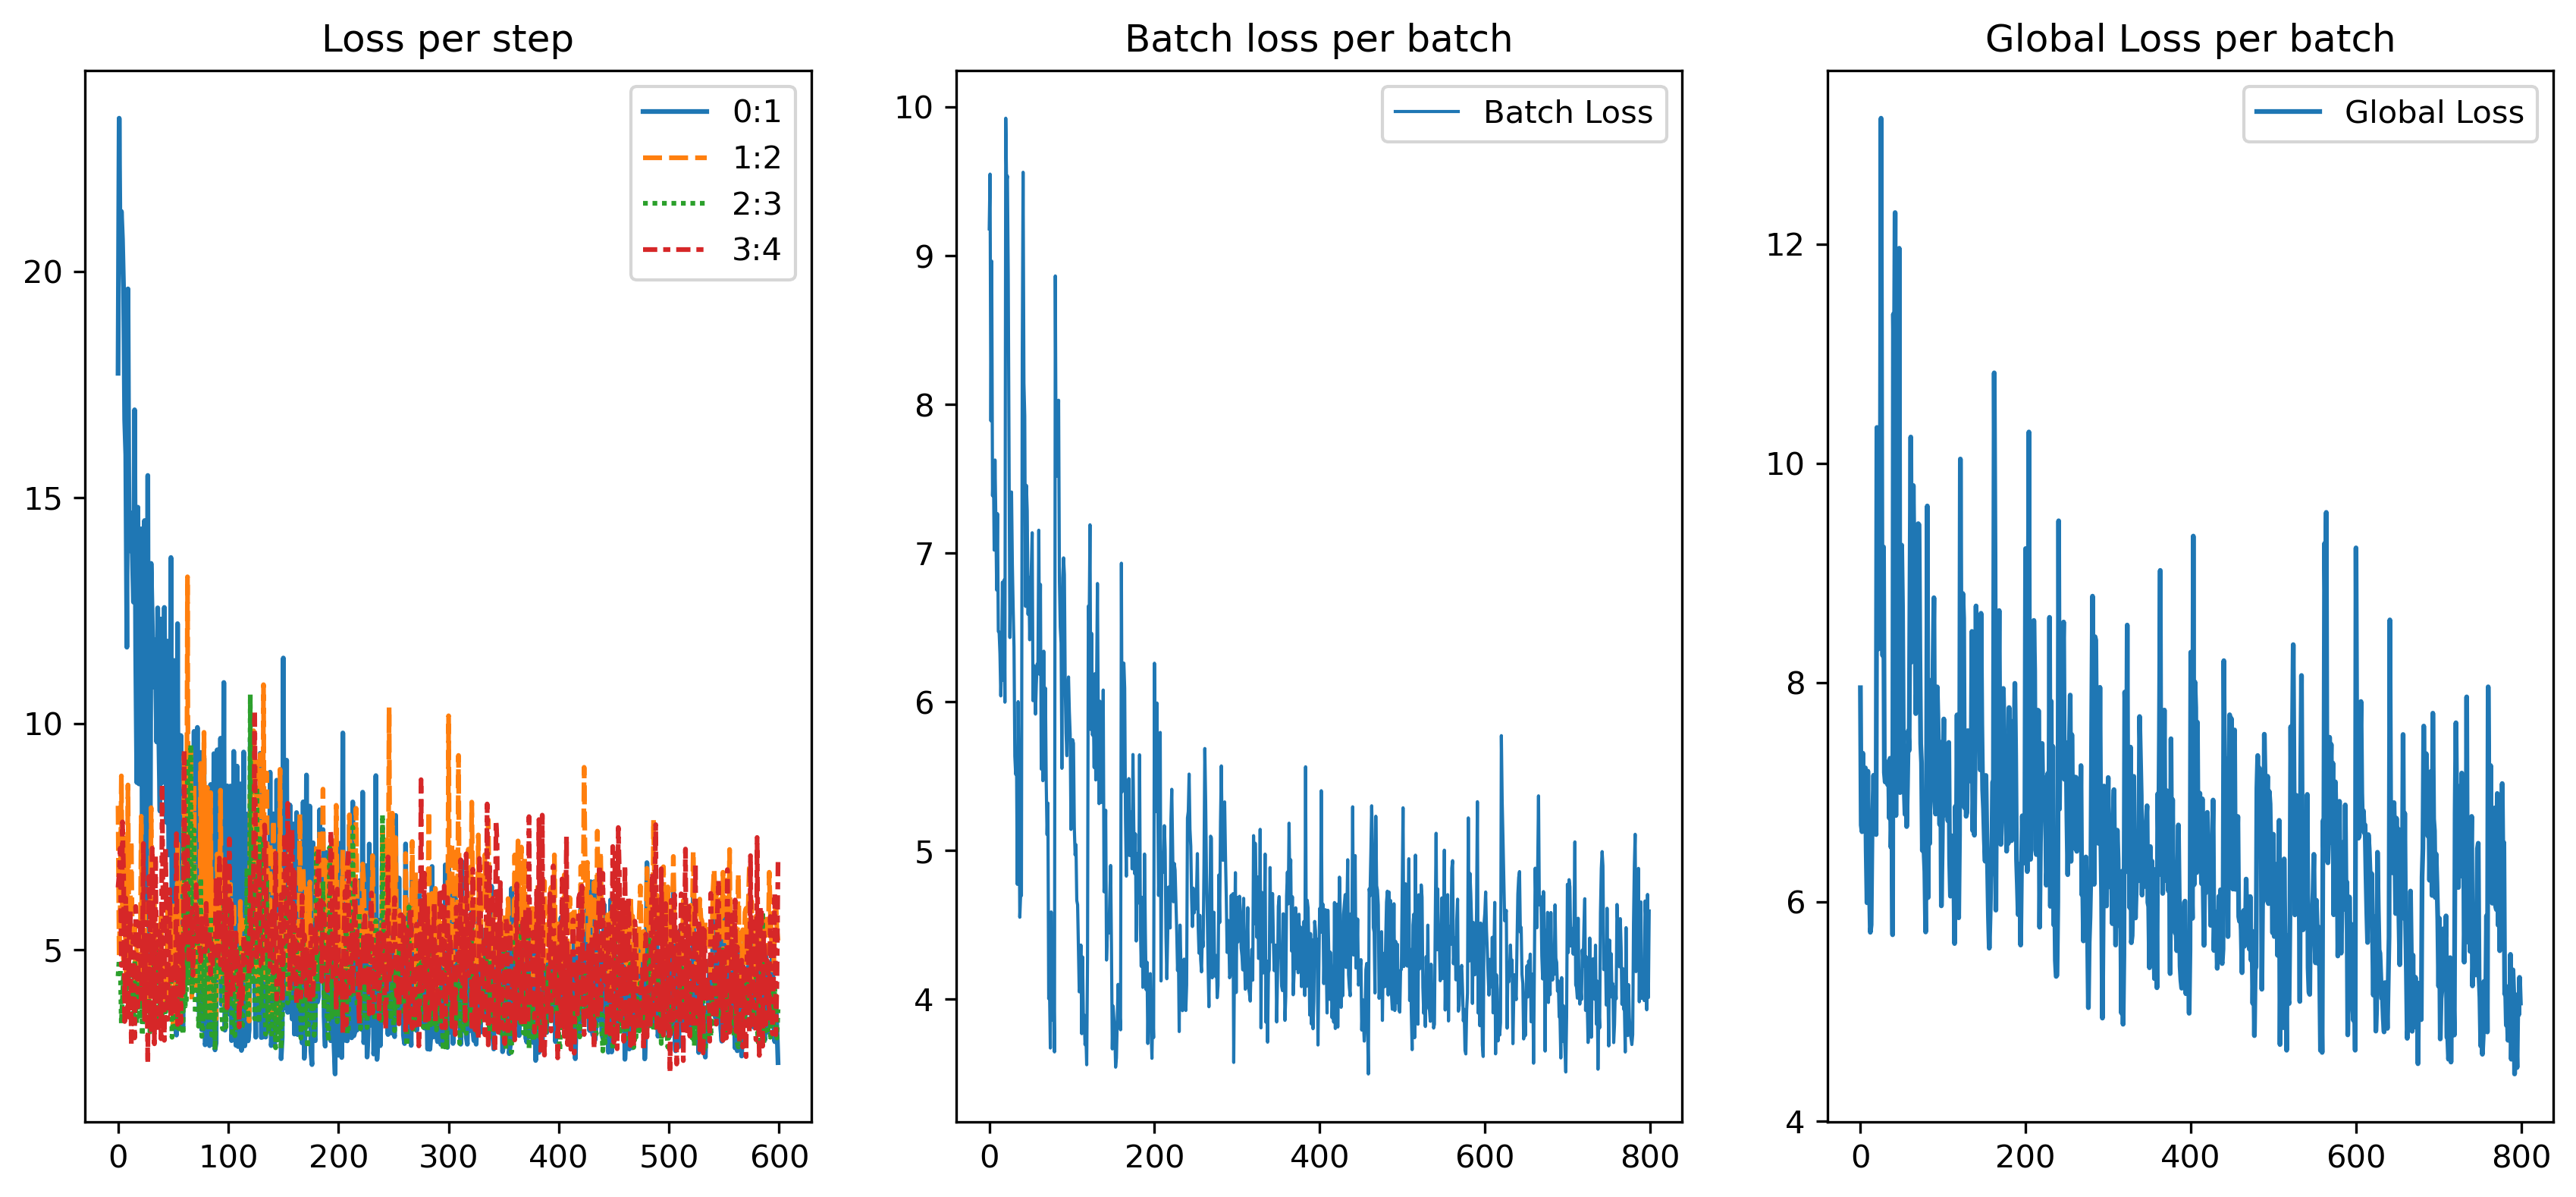

In [27]:
plot_losses(
    local_losses, 
    batch_losses, 
    globe_losses, 
    save=True, 
    path=SAVE_PATH, 
    file='losses.png'
)

In [28]:
generated, trajectoriespts = generate_plot_data(
    model, 
    df, 
    n_points=100, 
    n_trajectories=100, 
    n_bins=100, 
    use_cuda=use_cuda, 
    samples_key='samples', 
    logger=None,
    autoencoder=None, 
    recon=None
)

## Visualizing the MIOFlow Outputs and saving

In [29]:
trajectoriespts = trajectoriespts * std_vals + mean_vals
generated = generated * std_vals + mean_vals
true_data = df[[f'd{i}' for i in range(1, len(df.columns))]] * std_vals + mean_vals

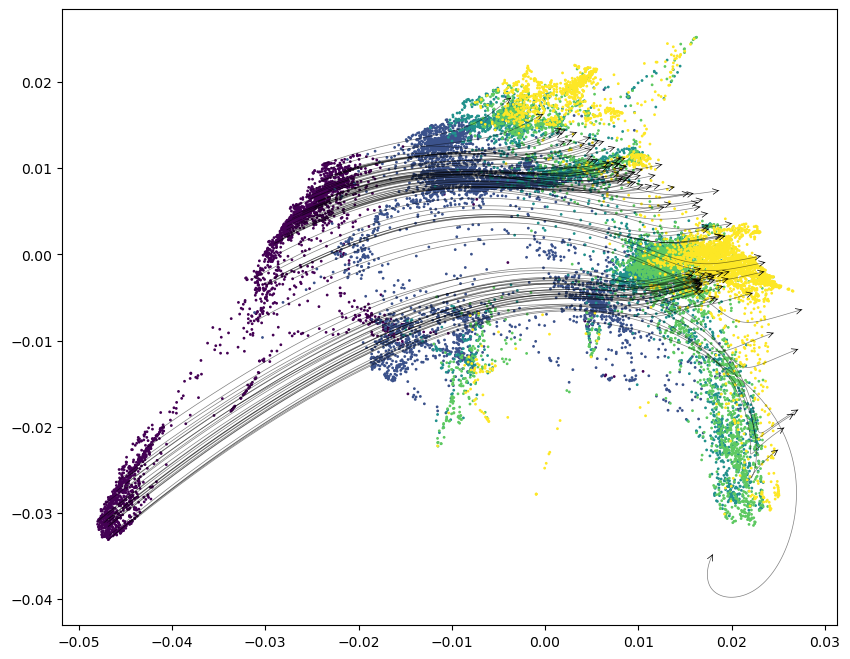

In [30]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(true_data.values[:, 0], true_data.values[:, 1], c=df['samples'].values, cmap='viridis', s=1)
for i,traj in enumerate(np.transpose(trajectoriespts, axes=(1,0,2))):
    # widths = m_traj[:,i]
    plt.plot(traj[:, 0], traj[:, 1], alpha=.5, linewidth=.5, color='Black')
    plt.annotate('', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
                 arrowprops=dict(arrowstyle='->', color='Black', lw=.5, mutation_scale=10))